# HW10-11
## Часть A (S10): классификация изображений, аугментации и transfer learning

В этой части используется датасет CIFAR100 из torchvision.

План экспериментов:
- C1: simple-cnn-base
- C2: simple-cnn-aug
- C3: resnet18-head-only
- C4: resnet18-finetune

Лучшая модель выбирается по validation accuracy.
Test используется один раз в конце для лучшей модели.

In [1]:
# Базовые библиотеки
import os
import json
import time
import copy
import random
import csv
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from torchvision.models import ResNet18_Weights

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True

In [2]:
SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [3]:
ARTIFACTS_DIR = Path("artifacts")
FIGURES_DIR = ARTIFACTS_DIR / "figures"
DATA_DIR = Path("data")

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

RUNS_CSV_PATH = ARTIFACTS_DIR / "runs.csv"
BEST_MODEL_PATH = ARTIFACTS_DIR / "best_classifier.pt"
BEST_CONFIG_PATH = ARTIFACTS_DIR / "best_classifier_config.json"

CLASSIFICATION_CURVES_BEST_PATH = FIGURES_DIR / "classification_curves_best.png"
CLASSIFICATION_COMPARE_PATH = FIGURES_DIR / "classification_compare.png"
AUGMENTATIONS_PREVIEW_PATH = FIGURES_DIR / "augmentations_preview.png"

print("Artifacts:", ARTIFACTS_DIR.resolve())
print("Figures  :", FIGURES_DIR.resolve())
print("Data     :", DATA_DIR.resolve())

Artifacts: C:\Users\anark\am-nom3\homeworks\HW10-11\artifacts
Figures  : C:\Users\anark\am-nom3\homeworks\HW10-11\artifacts\figures
Data     : C:\Users\anark\am-nom3\homeworks\HW10-11\data


In [ ]:
@dataclass
class DataConfig:
    dataset_name: str = "CIFAR100"   
    data_root: str = "./data"
    batch_size: int = 64
    val_ratio: float = 0.2
    num_workers: int = 0
    pin_memory: bool = torch.cuda.is_available()

data_config = DataConfig()
data_config

DataConfig(dataset_name='CIFAR100', data_root='./data', batch_size=64, val_ratio=0.2, num_workers=0, pin_memory=False)

In [5]:
def get_num_classes(dataset_name: str) -> int:
    dataset_name = dataset_name.upper()

    if dataset_name == "CIFAR100":
        return 100
    if dataset_name == "STL10":
        return 10
    if dataset_name == "SVHN":
        return 10
    if dataset_name == "FLOWERS102":
        return 102

    raise ValueError(f"Unsupported dataset: {dataset_name}")

In [27]:
def get_transforms(dataset_name: str):
    dataset_name = dataset_name.upper()

    # Базовый transform для простой CNN
    base_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ])

    # Более легкий transform с аугментациями
    aug_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomCrop(size=32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ])

    # Уменьшаем размер для ResNet, чтобы ускорить обучение на CPU
    resnet_size = 160
    resnet_weights = ResNet18_Weights.DEFAULT

    resnet_train_transform = transforms.Compose([
        transforms.Resize((resnet_size, resnet_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomResizedCrop(size=resnet_size, scale=(0.85, 1.0)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=resnet_weights.transforms().mean,
            std=resnet_weights.transforms().std,
        ),
    ])

    resnet_eval_transform = transforms.Compose([
        transforms.Resize((resnet_size, resnet_size)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=resnet_weights.transforms().mean,
            std=resnet_weights.transforms().std,
        ),
    ])

    return {
        "base": base_transform,
        "aug": aug_transform,
        "resnet_train": resnet_train_transform,
        "resnet_eval": resnet_eval_transform,
    }

In [7]:
class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        x, y = self.subset[idx]
        if self.transform is not None:
            x = self.transform(x)
        return x, y

In [8]:
def load_classification_datasets(config: DataConfig):
    dataset_name = config.dataset_name.upper()
    tfms = get_transforms(dataset_name)

    if dataset_name == "CIFAR100":
        train_full_raw = datasets.CIFAR100(
            root=config.data_root,
            train=True,
            download=True,
            transform=None,
        )
        test_raw = datasets.CIFAR100(
            root=config.data_root,
            train=False,
            download=True,
            transform=None,
        )
        class_names = train_full_raw.classes
        input_shape = (3, 32, 32)

    elif dataset_name == "SVHN":
        train_full_raw = datasets.SVHN(
            root=config.data_root,
            split="train",
            download=True,
            transform=None,
        )
        test_raw = datasets.SVHN(
            root=config.data_root,
            split="test",
            download=True,
            transform=None,
        )
        class_names = [str(i) for i in range(10)]
        input_shape = (3, 32, 32)

    elif dataset_name == "STL10":
        train_full_raw = datasets.STL10(
            root=config.data_root,
            split="train",
            download=True,
            transform=None,
        )
        test_raw = datasets.STL10(
            root=config.data_root,
            split="test",
            download=True,
            transform=None,
        )
        class_names = train_full_raw.classes
        input_shape = (3, 96, 96)

    elif dataset_name == "FLOWERS102":
        train_full_raw = datasets.Flowers102(
            root=config.data_root,
            split="train",
            download=True,
            transform=None,
        )
        test_raw = datasets.Flowers102(
            root=config.data_root,
            split="test",
            download=True,
            transform=None,
        )
        class_names = [f"class_{i}" for i in range(102)]
        input_shape = (3, 224, 224)

    else:
        raise ValueError(f"Unsupported dataset: {dataset_name}")

    train_size = int(len(train_full_raw) * (1 - config.val_ratio))
    val_size = len(train_full_raw) - train_size

    generator = torch.Generator().manual_seed(SEED)
    train_subset_raw, val_subset_raw = random_split(
        train_full_raw,
        [train_size, val_size],
        generator=generator,
    )

    num_classes = get_num_classes(dataset_name)

    result = {
        "train_raw": train_subset_raw,
        "val_raw": val_subset_raw,
        "test_raw": test_raw,
        "class_names": class_names,
        "input_shape": input_shape,
        "num_classes": num_classes,
        "transforms": tfms,
    }
    return result

In [9]:
classification_data = load_classification_datasets(data_config)

print("Dataset      :", data_config.dataset_name)
print("Train split  :", len(classification_data["train_raw"]))
print("Val split    :", len(classification_data["val_raw"]))
print("Test split   :", len(classification_data["test_raw"]))
print("Input shape  :", classification_data["input_shape"])
print("Num classes  :", classification_data["num_classes"])

100%|██████████| 169M/169M [05:12<00:00, 540kB/s]  


Dataset      : CIFAR100
Train split  : 40000
Val split    : 10000
Test split   : 10000
Input shape  : (3, 32, 32)
Num classes  : 100


In [10]:
def denormalize_image(img_tensor):
    img = img_tensor.detach().cpu().clone()
    mean = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
    std = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
    img = img * std + mean
    img = img.clamp(0, 1)
    return img

In [11]:
def show_augmentations_preview(raw_dataset, aug_transform, save_path=None, n=5):
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    image, label = raw_dataset[0]

    for i in range(n):
        aug_img = aug_transform(image)
        aug_img = denormalize_image(aug_img)
        axes[i].imshow(np.transpose(aug_img.numpy(), (1, 2, 0)))
        axes[i].set_title(f"aug #{i+1}")
        axes[i].axis("off")

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

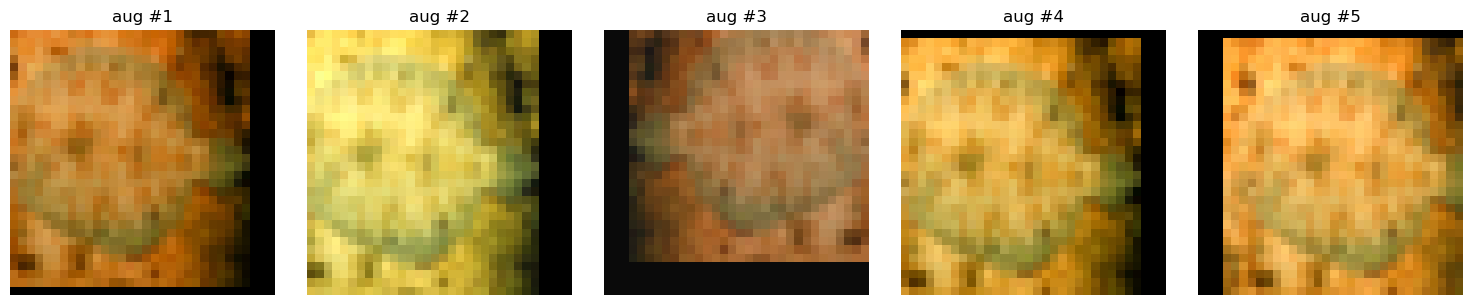

In [12]:
show_augmentations_preview(
    raw_dataset=classification_data["train_raw"],
    aug_transform=classification_data["transforms"]["aug"],
    save_path=AUGMENTATIONS_PREVIEW_PATH,
    n=5,
)

In [13]:
def build_classification_loaders(raw_data_dict, config: DataConfig, mode: str):
    assert mode in {"cnn_base", "cnn_aug", "resnet"}

    if mode == "cnn_base":
        train_dataset = TransformSubset(raw_data_dict["train_raw"], transform=raw_data_dict["transforms"]["base"])
        val_dataset = TransformSubset(raw_data_dict["val_raw"], transform=raw_data_dict["transforms"]["base"])
        test_dataset = TransformSubset(raw_data_dict["test_raw"], transform=raw_data_dict["transforms"]["base"])

    elif mode == "cnn_aug":
        train_dataset = TransformSubset(raw_data_dict["train_raw"], transform=raw_data_dict["transforms"]["aug"])
        val_dataset = TransformSubset(raw_data_dict["val_raw"], transform=raw_data_dict["transforms"]["base"])
        test_dataset = TransformSubset(raw_data_dict["test_raw"], transform=raw_data_dict["transforms"]["base"])

    elif mode == "resnet":
        train_dataset = TransformSubset(raw_data_dict["train_raw"], transform=raw_data_dict["transforms"]["resnet_train"])
        val_dataset = TransformSubset(raw_data_dict["val_raw"], transform=raw_data_dict["transforms"]["resnet_eval"])
        test_dataset = TransformSubset(raw_data_dict["test_raw"], transform=raw_data_dict["transforms"]["resnet_eval"])

    train_loader = DataLoader(
        train_dataset,
        batch_size=config.batch_size,
        shuffle=True,
        num_workers=config.num_workers,
        pin_memory=config.pin_memory,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.num_workers,
        pin_memory=config.pin_memory,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.num_workers,
        pin_memory=config.pin_memory,
    )

    return train_loader, val_loader, test_loader

In [14]:
train_loader_preview, val_loader_preview, test_loader_preview = build_classification_loaders(
    classification_data,
    data_config,
    mode="cnn_base",
)

x_batch, y_batch = next(iter(train_loader_preview))
print("x.shape:", x_batch.shape)
print("y.shape:", y_batch.shape)
print("x.dtype:", x_batch.dtype)
print("y.dtype:", y_batch.dtype)

x.shape: torch.Size([128, 3, 32, 32])
y.shape: torch.Size([128])
x.dtype: torch.float32
y.dtype: torch.int64


In [15]:
def show_batch(images, labels, class_names=None, n=8):
    n = min(n, len(images))
    plt.figure(figsize=(14, 4))

    for i in range(n):
        plt.subplot(2, 4, i + 1)
        img = denormalize_image(images[i])
        plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
        if class_names is not None and int(labels[i]) < len(class_names):
            plt.title(class_names[int(labels[i])])
        else:
            plt.title(str(int(labels[i])))
        plt.axis("off")

    plt.tight_layout()
    plt.show()

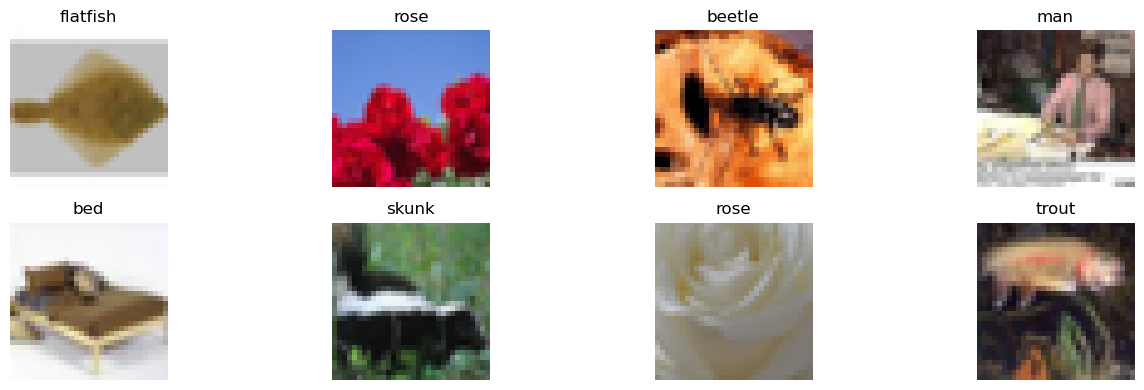

In [16]:
show_batch(x_batch, y_batch, class_names=classification_data["class_names"], n=8)

In [17]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
def build_resnet18_model(num_classes: int, mode: str):
    assert mode in {"head_only", "finetune"}

    weights = ResNet18_Weights.DEFAULT
    model = models.resnet18(weights=weights)

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    if mode == "head_only":
        for param in model.parameters():
            param.requires_grad = False
        for param in model.fc.parameters():
            param.requires_grad = True

    elif mode == "finetune":
        for param in model.parameters():
            param.requires_grad = False
        for param in model.layer4.parameters():
            param.requires_grad = True
        for param in model.fc.parameters():
            param.requires_grad = True

    return model

In [19]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    running_correct = 0
    total = 0

    for x, y in dataloader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == y).sum().item()
        total += x.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total

    return epoch_loss, epoch_acc

In [20]:
@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_correct = 0
    total = 0

    for x, y in dataloader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        running_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == y).sum().item()
        total += x.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total

    return epoch_loss, epoch_acc

In [21]:
def plot_history(history, title=None, save_path=None):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], marker="o", label="train_loss")
    plt.plot(epochs, history["val_loss"], marker="o", label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss" if title is None else f"{title} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], marker="o", label="train_acc")
    plt.plot(epochs, history["val_acc"], marker="o", label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy" if title is None else f"{title} - Accuracy")
    plt.legend()

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()

In [22]:
def append_run_to_csv(row, csv_path=RUNS_CSV_PATH):
    fieldnames = [
        "experiment_id",
        "task",
        "dataset",
        "seed",
        "model_summary",
        "optimizer",
        "lr",
        "epochs_trained",
        "best_val_accuracy",
        "test_accuracy",
        "precision",
        "recall",
        "mean_iou",
        "notes",
    ]

    file_exists = csv_path.exists()

    with open(csv_path, "a", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        if not file_exists:
            writer.writeheader()
        writer.writerow(row)

In [23]:
def run_classification_experiment(
    experiment_id,
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs,
    model_summary,
    optimizer_name,
    lr,
    notes="",
):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    best_val_acc = -1.0
    best_state_dict = None

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state_dict = copy.deepcopy(model.state_dict())

        print(
            f"{experiment_id} | "
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} | "
            f"train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_acc={val_acc:.4f}"
        )

    model.load_state_dict(best_state_dict)

    append_run_to_csv({
        "experiment_id": experiment_id,
        "task": "classification",
        "dataset": data_config.dataset_name,
        "seed": SEED,
        "model_summary": model_summary,
        "optimizer": optimizer_name,
        "lr": lr,
        "epochs_trained": epochs,
        "best_val_accuracy": best_val_acc,
        "test_accuracy": "",
        "precision": "",
        "recall": "",
        "mean_iou": "",
        "notes": notes,
    })

    return {
        "experiment_id": experiment_id,
        "model": model,
        "history": history,
        "best_val_accuracy": best_val_acc,
    }

In [28]:
classification_experiments = {
    "C1": {
        "loader_mode": "cnn_base",
        "model_type": "simple_cnn",
        "epochs": 6,
        "lr": 1e-3,
        "optimizer_name": "Adam",
        "notes": "simple-cnn-base-fast",
    },
    "C2": {
        "loader_mode": "cnn_aug",
        "model_type": "simple_cnn",
        "epochs": 6,
        "lr": 1e-3,
        "optimizer_name": "Adam",
        "notes": "simple-cnn-aug-fast",
    },
    "C3": {
        "loader_mode": "resnet",
        "model_type": "resnet18_head_only",
        "epochs": 3,
        "lr": 1e-3,
        "optimizer_name": "Adam",
        "notes": "resnet18-head-only-fast",
    },
    "C4": {
        "loader_mode": "resnet",
        "model_type": "resnet18_finetune",
        "epochs": 3,
        "lr": 1e-4,
        "optimizer_name": "Adam",
        "notes": "resnet18-finetune-fast",
    },
}
classification_experiments

{'C1': {'loader_mode': 'cnn_base',
  'model_type': 'simple_cnn',
  'epochs': 6,
  'lr': 0.001,
  'optimizer_name': 'Adam',
  'notes': 'simple-cnn-base-fast'},
 'C2': {'loader_mode': 'cnn_aug',
  'model_type': 'simple_cnn',
  'epochs': 6,
  'lr': 0.001,
  'optimizer_name': 'Adam',
  'notes': 'simple-cnn-aug-fast'},
 'C3': {'loader_mode': 'resnet',
  'model_type': 'resnet18_head_only',
  'epochs': 3,
  'lr': 0.001,
  'optimizer_name': 'Adam',
  'notes': 'resnet18-head-only-fast'},
 'C4': {'loader_mode': 'resnet',
  'model_type': 'resnet18_finetune',
  'epochs': 3,
  'lr': 0.0001,
  'optimizer_name': 'Adam',
  'notes': 'resnet18-finetune-fast'}}

In [29]:
classification_results = {}

for experiment_id, cfg in classification_experiments.items():
    print("=" * 100)
    print(experiment_id, cfg)

    train_loader, val_loader, test_loader = build_classification_loaders(
        classification_data,
        data_config,
        mode=cfg["loader_mode"],
    )

    if cfg["model_type"] == "simple_cnn":
        model = SimpleCNN(num_classes=classification_data["num_classes"]).to(device)
        model_summary = "SimpleCNN(3 conv blocks, classifier 128->256->num_classes)"

    elif cfg["model_type"] == "resnet18_head_only":
        model = build_resnet18_model(
            num_classes=classification_data["num_classes"],
            mode="head_only",
        ).to(device)
        model_summary = "ResNet18 pretrained, head-only"

    elif cfg["model_type"] == "resnet18_finetune":
        model = build_resnet18_model(
            num_classes=classification_data["num_classes"],
            mode="finetune",
        ).to(device)
        model_summary = "ResNet18 pretrained, layer4+fc fine-tune"

    params_to_update = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(params_to_update, lr=cfg["lr"])
    criterion = nn.CrossEntropyLoss()

    result = run_classification_experiment(
        experiment_id=experiment_id,
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        epochs=cfg["epochs"],
        model_summary=model_summary,
        optimizer_name=cfg["optimizer_name"],
        lr=cfg["lr"],
        notes=cfg["notes"],
    )

    classification_results[experiment_id] = {
        **result,
        "config": cfg,
    }

C1 {'loader_mode': 'cnn_base', 'model_type': 'simple_cnn', 'epochs': 6, 'lr': 0.001, 'optimizer_name': 'Adam', 'notes': 'simple-cnn-base-fast'}
C1 | Epoch 01/6 | train_loss=4.0932 | train_acc=0.0644 | val_loss=3.7788 | val_acc=0.1126
C1 | Epoch 02/6 | train_loss=3.6573 | train_acc=0.1244 | val_loss=3.5137 | val_acc=0.1574
C1 | Epoch 03/6 | train_loss=3.4102 | train_acc=0.1718 | val_loss=3.2851 | val_acc=0.2024
C1 | Epoch 04/6 | train_loss=3.2126 | train_acc=0.2084 | val_loss=3.1072 | val_acc=0.2383
C1 | Epoch 05/6 | train_loss=3.0406 | train_acc=0.2376 | val_loss=2.9656 | val_acc=0.2658
C1 | Epoch 06/6 | train_loss=2.8988 | train_acc=0.2668 | val_loss=2.8536 | val_acc=0.2823
C2 {'loader_mode': 'cnn_aug', 'model_type': 'simple_cnn', 'epochs': 6, 'lr': 0.001, 'optimizer_name': 'Adam', 'notes': 'simple-cnn-aug-fast'}
C2 | Epoch 01/6 | train_loss=4.2309 | train_acc=0.0473 | val_loss=3.8428 | val_acc=0.0935
C2 | Epoch 02/6 | train_loss=3.7621 | train_acc=0.1097 | val_loss=3.5258 | val_acc=0

In [30]:
for experiment_id in ["C1", "C2", "C3", "C4"]:
    result = classification_results[experiment_id]
    print(
        f"{experiment_id} | "
        f"best_val_accuracy={result['best_val_accuracy']:.4f} | "
        f"notes={result['config']['notes']}"
    )

C1 | best_val_accuracy=0.2823 | notes=simple-cnn-base-fast
C2 | best_val_accuracy=0.2746 | notes=simple-cnn-aug-fast
C3 | best_val_accuracy=0.5498 | notes=resnet18-head-only-fast
C4 | best_val_accuracy=0.7134 | notes=resnet18-finetune-fast



=== C1 ===


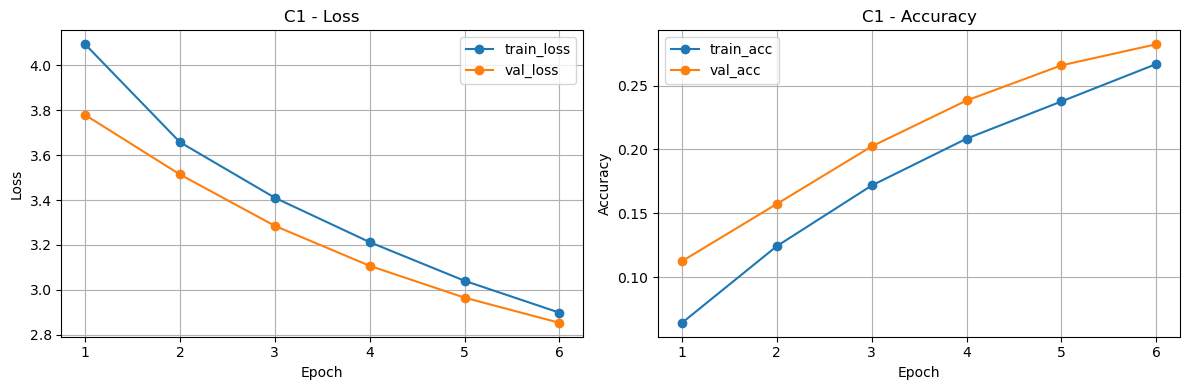


=== C2 ===


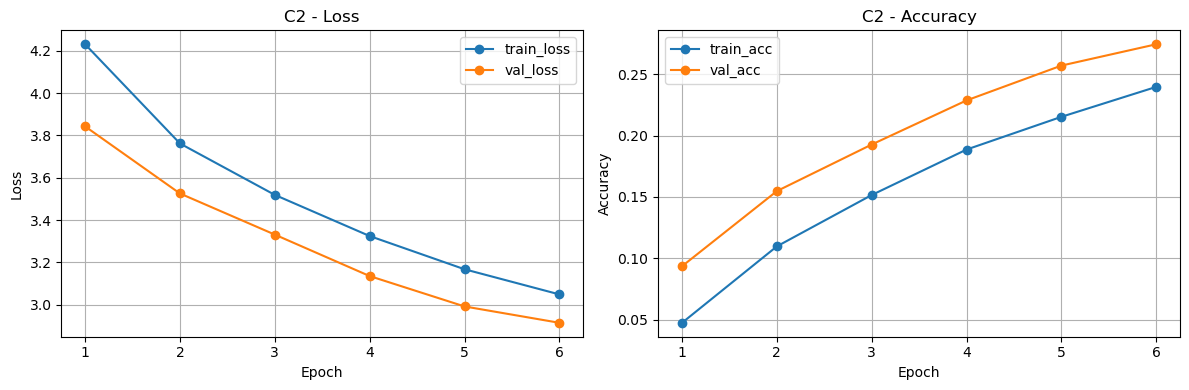


=== C3 ===


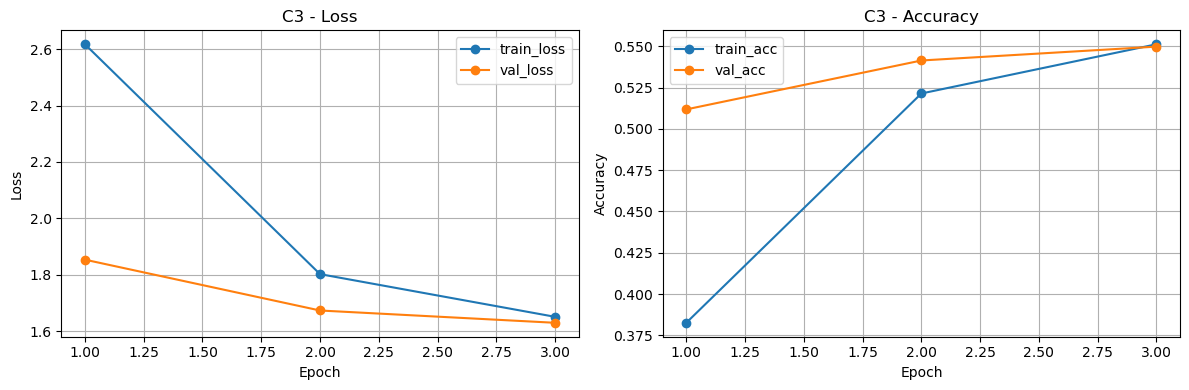


=== C4 ===


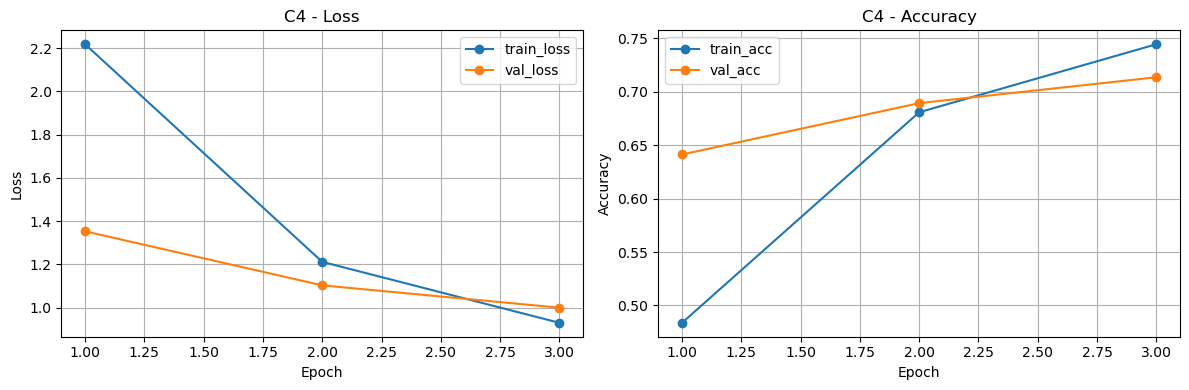

In [31]:
for experiment_id in ["C1", "C2", "C3", "C4"]:
    print(f"\n=== {experiment_id} ===")
    plot_history(classification_results[experiment_id]["history"], title=experiment_id)

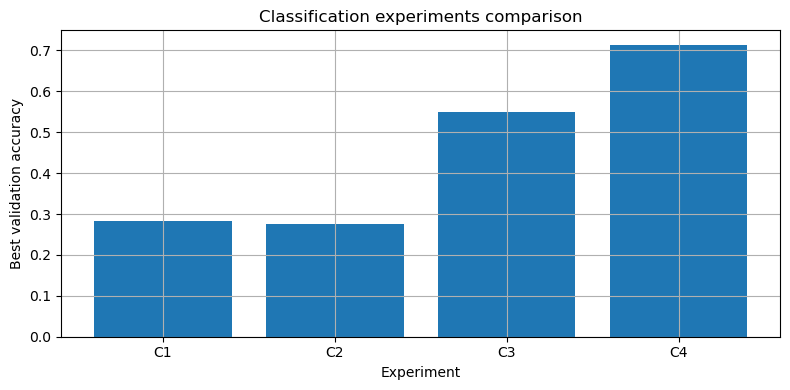

In [32]:
exp_ids = ["C1", "C2", "C3", "C4"]
val_accs = [classification_results[exp_id]["best_val_accuracy"] for exp_id in exp_ids]

plt.figure(figsize=(8, 4))
plt.bar(exp_ids, val_accs)
plt.xlabel("Experiment")
plt.ylabel("Best validation accuracy")
plt.title("Classification experiments comparison")
plt.tight_layout()
plt.savefig(CLASSIFICATION_COMPARE_PATH, dpi=150, bbox_inches="tight")
plt.show()

In [33]:
best_experiment_id = max(
    classification_results.keys(),
    key=lambda x: classification_results[x]["best_val_accuracy"]
)

best_result = classification_results[best_experiment_id]
print("Best classification experiment:", best_experiment_id)
print("Best val accuracy:", best_result["best_val_accuracy"])

Best classification experiment: C4
Best val accuracy: 0.7134


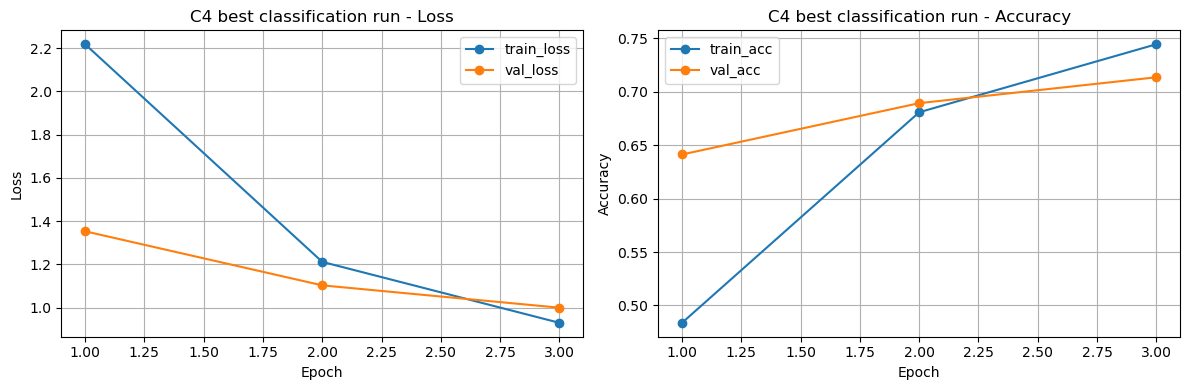

Saved model : C:\Users\anark\am-nom3\homeworks\HW10-11\artifacts\best_classifier.pt
Saved config: C:\Users\anark\am-nom3\homeworks\HW10-11\artifacts\best_classifier_config.json


In [34]:
torch.save(best_result["model"].state_dict(), BEST_MODEL_PATH)

best_config_to_save = {
    "experiment_id": best_experiment_id,
    "dataset": data_config.dataset_name,
    "seed": SEED,
    "batch_size": data_config.batch_size,
    "val_ratio": data_config.val_ratio,
    "num_classes": classification_data["num_classes"],
    "config": best_result["config"],
}

with open(BEST_CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(best_config_to_save, f, ensure_ascii=False, indent=2)

plot_history(
    best_result["history"],
    title=f"{best_experiment_id} best classification run",
    save_path=CLASSIFICATION_CURVES_BEST_PATH,
)

print("Saved model :", BEST_MODEL_PATH.resolve())
print("Saved config:", BEST_CONFIG_PATH.resolve())

In [35]:
best_cfg = best_result["config"]

_, _, best_test_loader = build_classification_loaders(
    classification_data,
    data_config,
    mode=best_cfg["loader_mode"],
)

test_loss, test_accuracy = evaluate(
    best_result["model"],
    best_test_loader,
    nn.CrossEntropyLoss(),
    device,
)

print("Final test metrics for the best classification model:")
print("test_loss:", test_loss)
print("test_accuracy:", test_accuracy)

Final test metrics for the best classification model:
test_loss: 0.9981579607009887
test_accuracy: 0.7126


In [36]:
with open(RUNS_CSV_PATH, "r", encoding="utf-8") as f:
    rows = list(csv.DictReader(f))

for row in rows:
    if row["experiment_id"] == best_experiment_id:
        row["test_accuracy"] = f"{test_accuracy:.6f}"

with open(RUNS_CSV_PATH, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=[
            "experiment_id",
            "task",
            "dataset",
            "seed",
            "model_summary",
            "optimizer",
            "lr",
            "epochs_trained",
            "best_val_accuracy",
            "test_accuracy",
            "precision",
            "recall",
            "mean_iou",
            "notes",
        ],
    )
    writer.writeheader()
    writer.writerows(rows)

print("runs.csv updated with final test_accuracy")

runs.csv updated with final test_accuracy


In [37]:
with open(RUNS_CSV_PATH, "r", encoding="utf-8") as f:
    print(f.read())

experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
C1,classification,CIFAR100,42,"SimpleCNN(3 conv blocks, classifier 128->256->num_classes)",Adam,0.001,10,0.2913,,,,,simple-cnn-base
C2,classification,CIFAR100,42,"SimpleCNN(3 conv blocks, classifier 128->256->num_classes)",Adam,0.001,10,0.2694,,,,,simple-cnn-aug
C1,classification,CIFAR100,42,"SimpleCNN(3 conv blocks, classifier 128->256->num_classes)",Adam,0.001,6,0.2823,,,,,simple-cnn-base-fast
C2,classification,CIFAR100,42,"SimpleCNN(3 conv blocks, classifier 128->256->num_classes)",Adam,0.001,6,0.2746,,,,,simple-cnn-aug-fast
C3,classification,CIFAR100,42,"ResNet18 pretrained, head-only",Adam,0.001,3,0.5498,,,,,resnet18-head-only-fast
C4,classification,CIFAR100,42,"ResNet18 pretrained, layer4+fc fine-tune",Adam,0.0001,3,0.7134,0.712600,,,,resnet18-finetune-fast



## Часть B (S11): segmentation track

Во второй части используется OxfordIIITPet и готовая pretrained segmentation-модель из torchvision.

Сравниваются два режима постобработки:

- V1: базовая постобработка маски
- V2: альтернативная постобработка маски (удаление маленьких компонент)

Метрики:
- mean_iou
- pixel_precision
- pixel_recall

In [38]:
from collections import deque

import torchvision.transforms.functional as TF
from torchvision.models.segmentation import (
    deeplabv3_resnet50,
    DeepLabV3_ResNet50_Weights,
)

In [39]:
SEGMENTATION_EXAMPLES_PATH = FIGURES_DIR / "segmentation_examples.png"
SEGMENTATION_METRICS_PATH = FIGURES_DIR / "segmentation_metrics.png"

print("Segmentation examples path:", SEGMENTATION_EXAMPLES_PATH.resolve())
print("Segmentation metrics path :", SEGMENTATION_METRICS_PATH.resolve())

Segmentation examples path: C:\Users\anark\am-nom3\homeworks\HW10-11\artifacts\figures\segmentation_examples.png
Segmentation metrics path : C:\Users\anark\am-nom3\homeworks\HW10-11\artifacts\figures\segmentation_metrics.png


In [40]:
@dataclass
class SegmentationConfig:
    dataset_name: str = "OxfordIIITPet"
    data_root: str = "./data"
    image_size: int = 256
    batch_size: int = 4
    num_workers: int = 0
    pin_memory: bool = torch.cuda.is_available()
    max_eval_samples: int = 80

seg_config = SegmentationConfig()
seg_config

SegmentationConfig(dataset_name='OxfordIIITPet', data_root='./data', image_size=256, batch_size=4, num_workers=0, pin_memory=False, max_eval_samples=80)

In [41]:
class PetSegmentationTransform:
    def __init__(self, image_size=256):
        self.image_size = image_size

    def __call__(self, image, target):
        image = TF.resize(image, [self.image_size, self.image_size])
        target = TF.resize(target, [self.image_size, self.image_size], interpolation=TF.InterpolationMode.NEAREST)

        image = TF.to_tensor(image)
        image = TF.normalize(
            image,
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        )

        target = torch.as_tensor(np.array(target), dtype=torch.int64)
        return image, target

In [42]:
class OxfordPetSegmentationDataset(torch.utils.data.Dataset):
    def __init__(self, root, split, transform=None):
        self.dataset = datasets.OxfordIIITPet(
            root=root,
            split=split,
            target_types="segmentation",
            download=True,
        )
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, target = self.dataset[idx]

        if self.transform is not None:
            image, target = self.transform(image, target)

        # foreground = class 1 (pet)
        binary_mask = (target == 1).long()

        return image, binary_mask

In [43]:
def load_segmentation_data(config: SegmentationConfig):
    transform = PetSegmentationTransform(image_size=config.image_size)

    full_trainval = OxfordPetSegmentationDataset(
        root=config.data_root,
        split="trainval",
        transform=transform,
    )

    test_dataset = OxfordPetSegmentationDataset(
        root=config.data_root,
        split="test",
        transform=transform,
    )

    train_size = int(len(full_trainval) * 0.8)
    val_size = len(full_trainval) - train_size

    generator = torch.Generator().manual_seed(SEED)
    train_dataset, val_dataset = random_split(
        full_trainval,
        [train_size, val_size],
        generator=generator,
    )

    return train_dataset, val_dataset, test_dataset

In [44]:
seg_train_dataset, seg_val_dataset, seg_test_dataset = load_segmentation_data(seg_config)

print("Segmentation dataset :", seg_config.dataset_name)
print("Train split          :", len(seg_train_dataset))
print("Val split            :", len(seg_val_dataset))
print("Test split           :", len(seg_test_dataset))

100%|██████████| 792M/792M [01:34<00:00, 8.37MB/s] 
100%|██████████| 19.2M/19.2M [00:01<00:00, 12.4MB/s]


Segmentation dataset : OxfordIIITPet
Train split          : 2944
Val split            : 736
Test split           : 3669


In [45]:
seg_train_loader = DataLoader(
    seg_train_dataset,
    batch_size=seg_config.batch_size,
    shuffle=False,
    num_workers=seg_config.num_workers,
    pin_memory=seg_config.pin_memory,
)

seg_val_loader = DataLoader(
    seg_val_dataset,
    batch_size=seg_config.batch_size,
    shuffle=False,
    num_workers=seg_config.num_workers,
    pin_memory=seg_config.pin_memory,
)

seg_test_loader = DataLoader(
    seg_test_dataset,
    batch_size=seg_config.batch_size,
    shuffle=False,
    num_workers=seg_config.num_workers,
    pin_memory=seg_config.pin_memory,
)

In [46]:
x_seg, y_seg = next(iter(seg_train_loader))

print("Segmentation batch:")
print("x.shape:", x_seg.shape)
print("y.shape:", y_seg.shape)
print("x.dtype:", x_seg.dtype)
print("y.dtype:", y_seg.dtype)
print("Unique mask values:", torch.unique(y_seg))

Segmentation batch:
x.shape: torch.Size([4, 3, 256, 256])
y.shape: torch.Size([4, 256, 256])
x.dtype: torch.float32
y.dtype: torch.int64
Unique mask values: tensor([0, 1])


In [47]:
def denormalize_imagenet(img_tensor):
    img = img_tensor.detach().cpu().clone()
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img * std + mean
    img = img.clamp(0, 1)
    return img

In [48]:
def show_segmentation_batch(images, masks, n=4):
    n = min(n, len(images))
    plt.figure(figsize=(12, 6))

    for i in range(n):
        plt.subplot(2, n, i + 1)
        img = denormalize_imagenet(images[i])
        plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
        plt.title("image")
        plt.axis("off")

        plt.subplot(2, n, n + i + 1)
        plt.imshow(masks[i].cpu(), cmap="gray")
        plt.title("mask")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

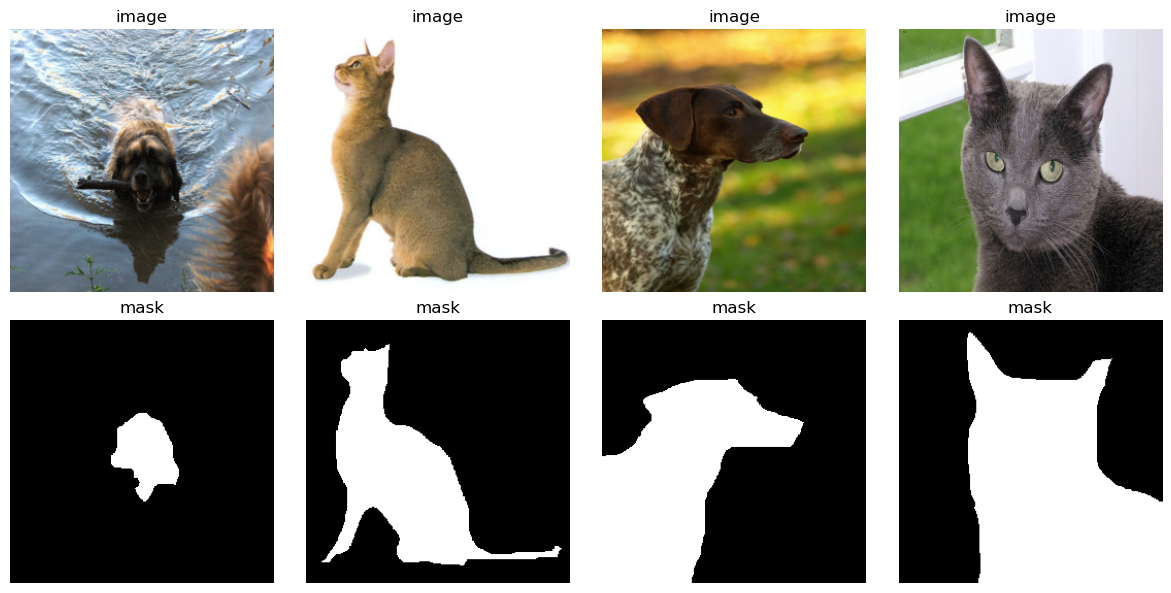

In [49]:
show_segmentation_batch(x_seg, y_seg, n=4)

In [50]:
seg_weights = DeepLabV3_ResNet50_Weights.DEFAULT
seg_model = deeplabv3_resnet50(weights=seg_weights).to(device)
seg_model.eval()

print("Segmentation model loaded on:", device)

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to C:\Users\anark/.cache\torch\hub\checkpoints\deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:09<00:00, 17.7MB/s] 


Segmentation model loaded on: cpu


In [51]:
@torch.no_grad()
def predict_foreground_logits(model, images, device):
    images = images.to(device)
    output = model(images)["out"]           # [B, C, H, W]
    probs = torch.softmax(output, dim=1)
    foreground_prob = 1.0 - probs[:, 0:1]   # foreground = not background
    return foreground_prob.cpu()

In [52]:
def postprocess_mask_v1(prob_mask, threshold=0.5):
    return (prob_mask >= threshold).long()

In [53]:
def remove_small_components(binary_mask, min_size=200):
    mask = binary_mask.squeeze().cpu().numpy().astype(np.uint8)
    h, w = mask.shape

    visited = np.zeros((h, w), dtype=bool)
    result = np.zeros((h, w), dtype=np.uint8)

    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    for i in range(h):
        for j in range(w):
            if mask[i, j] == 1 and not visited[i, j]:
                queue = deque([(i, j)])
                visited[i, j] = True
                component = [(i, j)]

                while queue:
                    x, y = queue.popleft()

                    for dx, dy in directions:
                        nx, ny = x + dx, y + dy
                        if 0 <= nx < h and 0 <= ny < w:
                            if mask[nx, ny] == 1 and not visited[nx, ny]:
                                visited[nx, ny] = True
                                queue.append((nx, ny))
                                component.append((nx, ny))

                if len(component) >= min_size:
                    for x, y in component:
                        result[x, y] = 1

    return torch.tensor(result, dtype=torch.long).unsqueeze(0)

In [54]:
def postprocess_mask_v2(prob_mask, threshold=0.5, min_component_size=200):
    binary = (prob_mask >= threshold).long()
    cleaned = remove_small_components(binary, min_size=min_component_size)
    return cleaned

In [55]:
def compute_binary_segmentation_metrics(pred_mask, true_mask):
    pred = pred_mask.view(-1).long()
    true = true_mask.view(-1).long()

    tp = ((pred == 1) & (true == 1)).sum().item()
    fp = ((pred == 1) & (true == 0)).sum().item()
    fn = ((pred == 0) & (true == 1)).sum().item()

    union = tp + fp + fn
    mean_iou = tp / union if union > 0 else 1.0

    pixel_precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    pixel_recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "mean_iou": mean_iou,
        "pixel_precision": pixel_precision,
        "pixel_recall": pixel_recall,
    }

In [56]:
@torch.no_grad()
def evaluate_segmentation_mode(
    model,
    dataloader,
    device,
    mode="V1",
    max_samples=None,
):
    assert mode in {"V1", "V2"}

    total_tp = 0
    total_fp = 0
    total_fn = 0
    iou_values = []

    processed = 0

    for images, true_masks in dataloader:
        probs = predict_foreground_logits(model, images, device)

        batch_size = images.size(0)

        for i in range(batch_size):
            prob_mask = probs[i]           # [1, H, W]
            true_mask = true_masks[i]      # [H, W]

            if mode == "V1":
                pred_mask = postprocess_mask_v1(prob_mask, threshold=0.5)
            else:
                pred_mask = postprocess_mask_v2(prob_mask, threshold=0.5, min_component_size=200)

            metrics = compute_binary_segmentation_metrics(
                pred_mask.squeeze(0),
                true_mask,
            )

            total_tp += metrics["tp"]
            total_fp += metrics["fp"]
            total_fn += metrics["fn"]
            iou_values.append(metrics["mean_iou"])

            processed += 1
            if max_samples is not None and processed >= max_samples:
                break

        if max_samples is not None and processed >= max_samples:
            break

    mean_iou = float(np.mean(iou_values)) if len(iou_values) > 0 else 0.0
    pixel_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    pixel_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0

    return {
        "mean_iou": mean_iou,
        "pixel_precision": pixel_precision,
        "pixel_recall": pixel_recall,
        "num_samples": processed,
    }

In [57]:
@torch.no_grad()
def collect_segmentation_examples(model, dataloader, device, n_examples=4):
    examples = []

    for images, true_masks in dataloader:
        probs = predict_foreground_logits(model, images, device)

        for i in range(images.size(0)):
            examples.append({
                "image": images[i].cpu(),
                "true_mask": true_masks[i].cpu(),
                "prob_mask": probs[i].cpu(),
            })
            if len(examples) >= n_examples:
                return examples

    return examples

In [58]:
def show_segmentation_predictions(examples, save_path=None):
    n = len(examples)
    plt.figure(figsize=(12, 3 * n))

    for i, ex in enumerate(examples):
        image = denormalize_imagenet(ex["image"])
        true_mask = ex["true_mask"]
        prob_mask = ex["prob_mask"]

        pred_v1 = postprocess_mask_v1(prob_mask, threshold=0.5).squeeze(0)
        pred_v2 = postprocess_mask_v2(prob_mask, threshold=0.5, min_component_size=200).squeeze(0)

        plt.subplot(n, 4, 4 * i + 1)
        plt.imshow(np.transpose(image.numpy(), (1, 2, 0)))
        plt.title("image")
        plt.axis("off")

        plt.subplot(n, 4, 4 * i + 2)
        plt.imshow(true_mask.numpy(), cmap="gray")
        plt.title("gt mask")
        plt.axis("off")

        plt.subplot(n, 4, 4 * i + 3)
        plt.imshow(pred_v1.numpy(), cmap="gray")
        plt.title("V1 pred")
        plt.axis("off")

        plt.subplot(n, 4, 4 * i + 4)
        plt.imshow(pred_v2.numpy(), cmap="gray")
        plt.title("V2 pred")
        plt.axis("off")

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

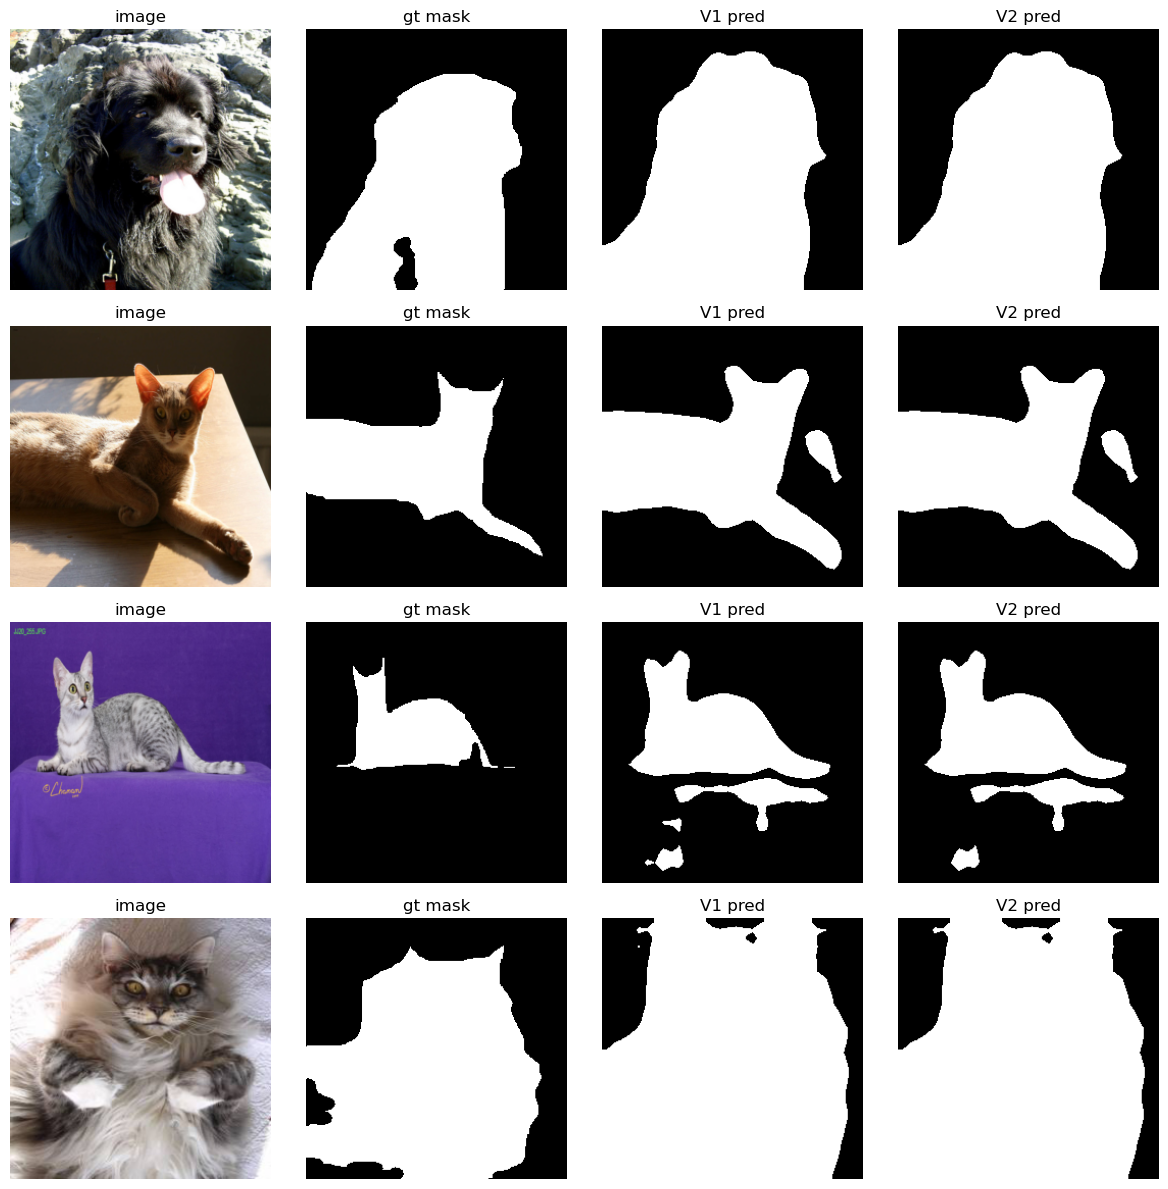

In [59]:
seg_examples = collect_segmentation_examples(
    seg_model,
    seg_val_loader,
    device=device,
    n_examples=4,
)

show_segmentation_predictions(
    seg_examples,
    save_path=SEGMENTATION_EXAMPLES_PATH,
)

In [60]:
segmentation_results = {}

for mode in ["V1", "V2"]:
    metrics = evaluate_segmentation_mode(
        model=seg_model,
        dataloader=seg_val_loader,
        device=device,
        mode=mode,
        max_samples=seg_config.max_eval_samples,
    )

    segmentation_results[mode] = metrics

    print(
        f"{mode} | "
        f"mean_iou={metrics['mean_iou']:.4f} | "
        f"pixel_precision={metrics['pixel_precision']:.4f} | "
        f"pixel_recall={metrics['pixel_recall']:.4f} | "
        f"num_samples={metrics['num_samples']}"
    )

V1 | mean_iou=0.6537 | pixel_precision=0.6560 | pixel_recall=0.9717 | num_samples=80
V2 | mean_iou=0.6540 | pixel_precision=0.6563 | pixel_recall=0.9717 | num_samples=80


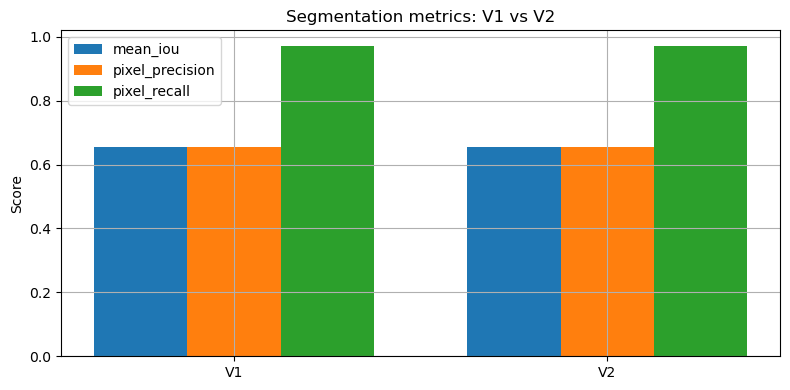

In [61]:
modes = ["V1", "V2"]
miou_vals = [segmentation_results[m]["mean_iou"] for m in modes]
prec_vals = [segmentation_results[m]["pixel_precision"] for m in modes]
rec_vals = [segmentation_results[m]["pixel_recall"] for m in modes]

x = np.arange(len(modes))
width = 0.25

plt.figure(figsize=(8, 4))
plt.bar(x - width, miou_vals, width=width, label="mean_iou")
plt.bar(x, prec_vals, width=width, label="pixel_precision")
plt.bar(x + width, rec_vals, width=width, label="pixel_recall")
plt.xticks(x, modes)
plt.ylabel("Score")
plt.title("Segmentation metrics: V1 vs V2")
plt.legend()
plt.tight_layout()
plt.savefig(SEGMENTATION_METRICS_PATH, dpi=150, bbox_inches="tight")
plt.show()

In [62]:
append_run_to_csv({
    "experiment_id": "V1",
    "task": "segmentation",
    "dataset": seg_config.dataset_name,
    "seed": SEED,
    "model_summary": "DeepLabV3_ResNet50 pretrained, binary foreground = not-background",
    "optimizer": "",
    "lr": "",
    "epochs_trained": 0,
    "best_val_accuracy": "",
    "test_accuracy": "",
    "precision": f"{segmentation_results['V1']['pixel_precision']:.6f}",
    "recall": f"{segmentation_results['V1']['pixel_recall']:.6f}",
    "mean_iou": f"{segmentation_results['V1']['mean_iou']:.6f}",
    "notes": "Segmentation V1: threshold=0.5",
})

append_run_to_csv({
    "experiment_id": "V2",
    "task": "segmentation",
    "dataset": seg_config.dataset_name,
    "seed": SEED,
    "model_summary": "DeepLabV3_ResNet50 pretrained, binary foreground = not-background",
    "optimizer": "",
    "lr": "",
    "epochs_trained": 0,
    "best_val_accuracy": "",
    "test_accuracy": "",
    "precision": f"{segmentation_results['V2']['pixel_precision']:.6f}",
    "recall": f"{segmentation_results['V2']['pixel_recall']:.6f}",
    "mean_iou": f"{segmentation_results['V2']['mean_iou']:.6f}",
    "notes": "Segmentation V2: threshold=0.5 + remove small components",
})

In [63]:
with open(RUNS_CSV_PATH, "r", encoding="utf-8") as f:
    print(f.read())

experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
C1,classification,CIFAR100,42,"SimpleCNN(3 conv blocks, classifier 128->256->num_classes)",Adam,0.001,10,0.2913,,,,,simple-cnn-base
C2,classification,CIFAR100,42,"SimpleCNN(3 conv blocks, classifier 128->256->num_classes)",Adam,0.001,10,0.2694,,,,,simple-cnn-aug
C1,classification,CIFAR100,42,"SimpleCNN(3 conv blocks, classifier 128->256->num_classes)",Adam,0.001,6,0.2823,,,,,simple-cnn-base-fast
C2,classification,CIFAR100,42,"SimpleCNN(3 conv blocks, classifier 128->256->num_classes)",Adam,0.001,6,0.2746,,,,,simple-cnn-aug-fast
C3,classification,CIFAR100,42,"ResNet18 pretrained, head-only",Adam,0.001,3,0.5498,,,,,resnet18-head-only-fast
C4,classification,CIFAR100,42,"ResNet18 pretrained, layer4+fc fine-tune",Adam,0.0001,3,0.7134,0.712600,,,,resnet18-finetune-fast
V1,segmentation,OxfordIIITPet,42,"DeepLabV3_ResNet50 pretrained, binary foreground = not